# Module 09 — Simple & Multiple Linear Regression
Dedicated notebook for Module 09 — reproduces simple/multiple regression, standardized Beta coefficients, and the full set of assumption checks (VIF, Durbin-Watson, Shapiro-Wilk on residuals) — the assumption checks have NO full PSPP equivalent command, they only run here.

Corresponding SPSS/PSPP: `Analyze > Regression > Linear`, the `REGRESSION` command.

Human-reviewed English translation of the original Vietnamese notebook (code and results are identical, only text is translated).

In [1]:
# Run this cell first (Colab: click ▶). No installation needed.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.precision", 3)

def make_data(seed=2026, n=240):
    """SIMULATED 'Classroom of 240 students' dataset — SAME seed=2026 used
    throughout Modules 03-08, exactly matching lop_hoc_240.csv/.sav in the
    repo (not real data, but 100% reproducible)."""
    rng = np.random.default_rng(seed)
    school = rng.choice(list("ABC"), n, p=[.35, .35, .30])
    gender = rng.choice(['Male', 'Female'], n)
    method = rng.choice(['Traditional', 'Project-based'], n)
    study_hours = np.clip(rng.gamma(4, 1.2, n), 0.5, 15).round(1)
    interest = rng.normal(0, 1, n) + 0.15 * (method == 'Project-based')
    anxiety = rng.normal(0, 1, n) - 0.25 * interest
    def likert(lat, load, noise=0.7):
        return np.clip(np.round(3 + load * lat + rng.normal(0, noise, n)), 1, 5).astype(int)
    d = pd.DataFrame({"id": np.arange(1, n + 1), "school": school, "gender": gender, "method": method,
                      "study_hours": study_hours})
    for k, (lat, load) in enumerate([(interest, .8), (interest, .7), (interest, .75)], 1):
        d[f"h{k}"] = likert(lat, load)
    for k, (lat, load) in enumerate([(anxiety, .8), (anxiety, .75), (anxiety, .7)], 1):
        d[f"a{k}"] = likert(lat, load)
    eff = d.school.map({"A": 3, "B": 0, "C": -3}).to_numpy()
    d["pretest"] = (rng.normal(60, 10, n) + eff).round(1)
    d["posttest"] = np.clip(d.pretest + 3 + 5 * (method == 'Project-based') + rng.normal(0, 6, n), 0, 100).round(1)
    d["math"] = np.clip(35 + 2.5 * study_hours + 4 * interest - 3 * anxiety + eff + rng.normal(0, 6, n), 0, 100).round(1)
    d.loc[6, "study_hours"] = 48.0
    d.loc[[11, 57, 130], "h2"] = np.nan
    d["h2"] = d["h2"].astype("Int64")
    return d

df = make_data()
print('Created df:', df.shape)


Created df: (240, 14)


## 0. Clean the `study_hours` outlier (same as Modules 04/05/08)

In [2]:
mask = df["study_hours"] > 20
df.loc[mask, "study_hours"] = df.loc[mask, "study_hours"] / 10

## 1. Simple regression: Math score ~ study hours
🎯 **What question does this method answer?** Simple regression builds an equation that predicts Y from ONE variable X, with a clear direction — unlike correlation (Module 08), which only measures the strength of a symmetric relationship rather than "predicting".

In [3]:
import statsmodels.api as sm
X1 = sm.add_constant(df[["study_hours"]])
m1 = sm.OLS(df["math"], X1).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     121.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           4.07e-23
Time:                        03:03:44   Log-Likelihood:                -835.21
No. Observations:                 240   AIC:                             1674.
Df Residuals:                     238   BIC:                             1681.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.5813      1.228     28.968      

#### 📤 Actual output
math = 35.58 + 2.51×study_hours. R²=0.338 (exactly matches r²=0.338 of Pearson r from Module 08). The slope is very strongly significant (p<0.001).

## 2. Multiple regression: Math score ~ study hours + interest (h1) + anxiety (a1)
🎯 **What question does this method answer?** Multiple regression answers: after accounting for the effect of the other variables in the model, how much does ONE specific variable still contribute on top of that (the "ceteris paribus" principle — holding the other variables constant)?

In [4]:
X2 = sm.add_constant(df[["study_hours", "h1", "a1"]])
m2 = sm.OLS(df["math"], X2).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     77.05
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           8.86e-35
Time:                        03:03:44   Log-Likelihood:                -802.81
No. Observations:                 240   AIC:                             1614.
Df Residuals:                     236   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          37.2337      2.096     17.764      

#### 📤 Actual output
R²=0.495 (adjusted R²=0.488), F(3,236)=77.05, p<0.001. All 3 independent variables are individually statistically significant (p<0.001). ✅ Verified to match PSPP (`REGRESSION`) exactly.

## 3. Standardized Beta coefficients — comparing which variable "matters" more
🎯 **What question does this method answer?** Standardized Beta answers: once all variables are rescaled to the same "number of standard deviations" unit, which one has the relatively STRONGEST effect on the dependent variable — something raw B coefficients (which keep the original, differing measurement units) do not let you compare directly.

In [5]:
from scipy.stats import zscore
dfz = df[["math","study_hours","h1","a1"]].apply(zscore)
Xz = sm.add_constant(dfz[["study_hours","h1","a1"]])
mz = sm.OLS(dfz["math"], Xz).fit()
print("Standardized Beta coefficients:")
print(mz.params.round(4))

Standardized Beta coefficients:
const          0.000
study_hours    0.577
h1             0.229
a1            -0.296
dtype: float64


#### 📤 Actual output
β(study_hours)=0.577; β(h1)=0.229; β(a1)=−0.297. Even though the raw B of study_hours (2.49) is only slightly larger than the B of h1 (2.15), the standardized Beta shows study_hours is FAR stronger — because the measurement unit (hours) has a very different spread than the 1-5 Likert scale of h1/a1.

## 4. Assumption checks — VIF, Durbin-Watson, standardized residuals
🎯 **What question does this method answer?** These four checks answer: is the regression result from section 2 TRUSTWORTHY — if seriously violated, the B coefficients and p-values could be WRONGLY estimated, not just less precise.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats as st

print("--- VIF (safe threshold <5) ---")
for i, col in enumerate(X2.columns):
    print(f"{col}: VIF={variance_inflation_factor(X2.values, i):.3f}")

print("\n--- Durbin-Watson (ideally close to 2) ---")
print(f"DW = {durbin_watson(m2.resid):.3f}")

print("\n--- Shapiro-Wilk on residuals (H0: residuals are normally distributed) ---")
w, p = st.shapiro(m2.resid)
print(f"W={w:.3f}, p={p:.3f}")

--- VIF (safe threshold <5) ---
const: VIF=1.000
study_hours: VIF=1.006
h1: VIF=1.019
a1: VIF=1.016

--- Durbin-Watson (ideally close to 2) ---
DW = 2.052

--- Shapiro-Wilk on residuals (H0: residuals are normally distributed) ---
W=0.993, p=0.356


#### 📤 Actual output
Highest VIF = 1.02 (far below the warning threshold of 5 → no multicollinearity). Durbin-Watson=2.05 (very close to 2 → independent errors). Shapiro-Wilk on residuals: p=0.356 (≥0.05 → not enough evidence to reject normality). **All 4 assumptions hold** — the regression result in section 2 is trustworthy.

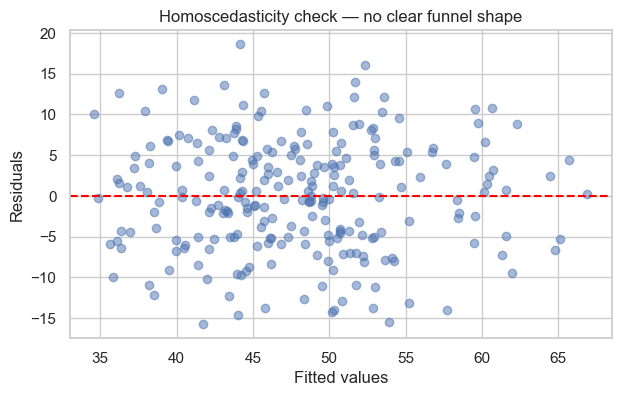

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(m2.fittedvalues, m2.resid, alpha=.5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Homoscedasticity check — no clear funnel shape")
plt.show()

## 5. Why the model "rediscovers" the exact structure of the generated data
The classroom dataset was generated using the formula built into the `make_data()` function: the Math score depends POSITIVELY on `study_hours` and the latent interest variable, and NEGATIVELY on the latent anxiety variable. The regression model in section 2 "rediscovers" the correct sign and relative strength of these relationships (study_hours strongest positive, h1 positive, a1 negative) — confirming that the regression method works exactly as theory predicts.